In [122]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [123]:
ds = xr.open_dataset(r"D:\my project\Climate Modelling\data\raw\historical_pr.nc")

print(ds)

<xarray.Dataset> Size: 20MB
Dimensions:    (time: 180, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2000-01-16T12:00:00 ... 2014-12-16T1...
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 3kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    pr         (time, lat, lon) float32 20MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-11-08T08:26:37Z
    ...                     ...
    variable_id:            pr
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_version:           3.4.0
    trac

In [124]:
print(ds["pr"].attrs)

{'standard_name': 'precipitation_flux', 'long_name': 'Precipitation', 'comment': 'includes both liquid and solid phases', 'units': 'kg m-2 s-1', 'cell_methods': 'area: time: mean', 'cell_measures': 'area: areacella', 'history': '2019-11-08T08:26:36Z altered by CMOR: replaced missing value flag (-1.07374e+09) with standard missing value (1e+20).'}


In [125]:
pr = ds["pr"]

punjab_pr = pr.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

pr_ts = punjab_pr.mean(
    dim=["lat","lon"]
)

In [126]:
pr_mm_day = pr_ts * 86400

In [127]:
monthly_pr = pr_mm_day.groupby(
    "time.month"
).mean()

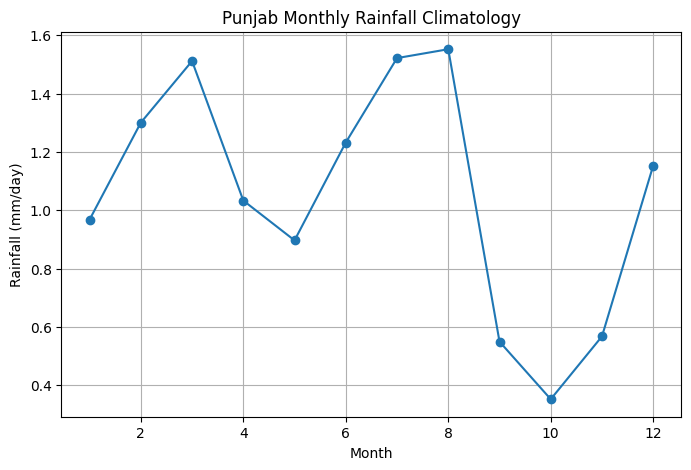

In [128]:
plt.figure(figsize=(8,5))

plt.plot(
    monthly_pr.month,
    monthly_pr.values,
    marker="o"
)

plt.title("Punjab Monthly Rainfall Climatology")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm/day)")
plt.grid()

plt.show()

In [129]:
pr = ds["pr"]

punjab_pr = pr.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

print(punjab_pr.shape)

(180, 6, 4)


In [130]:
pr_ts = punjab_pr.mean(
    dim=["lat","lon"]
)

print(pr_ts)

<xarray.DataArray 'pr' (time: 180)> Size: 720B
array([1.10058536e-05, 1.32820815e-05, 1.11610161e-05, 8.77951334e-06,
       1.02038784e-05, 7.58775423e-06, 2.30622991e-05, 6.53933466e-06,
       6.16454736e-06, 4.37489098e-06, 1.40528691e-05, 6.24594395e-06,
       2.75466882e-05, 1.92034404e-05, 2.23144216e-05, 1.02873501e-05,
       1.36205081e-05, 1.76633057e-05, 6.90643765e-06, 1.14170725e-05,
       6.45257933e-06, 4.93179641e-06, 1.04123421e-06, 1.56204587e-05,
       1.21556996e-05, 1.49327716e-05, 5.89422643e-06, 2.62345275e-05,
       6.52675226e-06, 1.59261454e-05, 1.24031185e-05, 3.73181283e-05,
       8.68351378e-07, 7.39746065e-06, 1.82246913e-06, 2.52856971e-05,
       8.06909611e-06, 1.28241518e-05, 1.64914018e-05, 8.49258231e-06,
       1.42313083e-05, 1.40295742e-05, 8.26982887e-06, 1.54684185e-05,
       6.07581524e-06, 2.31343779e-06, 2.93598205e-05, 1.99367496e-05,
       1.68046245e-05, 1.36067001e-05, 9.01917974e-06, 4.98396048e-06,
       1.00199914e-05, 9.18090

In [131]:
pr_mm_day = pr_ts * 86400

In [132]:
print(
    float(pr_mm_day.min()),
    float(pr_mm_day.max())
)

0.007005772087723017 4.495964050292969


In [133]:
monthly_pr = pr_mm_day.groupby(
    "time.month"
).mean()

In [134]:
for m, r in zip(
    monthly_pr.month.values,
    monthly_pr.values
):
    print(
        f"Month {m}: {r:.2f} mm/day"
    )

Month 1: 0.97 mm/day
Month 2: 1.30 mm/day
Month 3: 1.51 mm/day
Month 4: 1.03 mm/day
Month 5: 0.90 mm/day
Month 6: 1.23 mm/day
Month 7: 1.52 mm/day
Month 8: 1.55 mm/day
Month 9: 0.55 mm/day
Month 10: 0.35 mm/day
Month 11: 0.57 mm/day
Month 12: 1.15 mm/day


In [135]:
annual_rain = monthly_pr.sum()*30

print("Approx annual rainfall(mm):",
      float(annual_rain)

)

Approx annual rainfall(mm): 379.1658935546875


In [136]:
#Calculate Monsoon Share
monsoon = monthly_pr.sel(
    month = [6,7,8]
).sum()*30

annual = monthly_pr.sum()*30

print("Monsoon contribution(%)=",
      float(monsoon/annual*100)

)

Monsoon contribution(%)= 34.06646728515625


In [137]:
#SSP245 Precipitation
ds245 = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\pr_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-21001216.nc"
    
)
print(ds245)

<xarray.Dataset> Size: 114MB
Dimensions:    (time: 1032, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T1...
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 17kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    pr         (time, lat, lon) float32 114MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    creation_date:          2019-11-08T03:57:07Z
    ...                     ...
    variable_id:            pr
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_version:      

In [138]:
#punjab extrsction 
pr245 = ds245["pr"]

punjab245 = pr245.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

pr245_ts = punjab245.mean(
    dim=["lat","lon"]
)

In [139]:
#Convert To mm/day
pr245_mm = pr245_ts*86400

In [140]:
#Annual Rainfall Time Series
annual245 = pr245_mm.groupby(
    "time.year"
).mean()

In [141]:
#Calculate Future Period Means_Near Future
near245 = annual245.sel(
    year=slice(2021,2040)
).mean()

In [142]:
#mid century
mid245 = annual245.sel(
    year=slice(2041,2070)
).mean()

In [143]:
#Late Century
late245 = annual245.sel(
    year=slice(2071,2100)
).mean()

In [144]:
print("Near:", float(near245))
print("Mid :", float(mid245))
print("Late:", float(late245))

Near: 1.2641953229904175
Mid : 1.2419910430908203
Late: 1.2857552766799927


In [145]:
#Calculate Monthly Climatology
monthly245 = pr245_mm.sel(
    time=slice("2071","2100")
).groupby(
    "time.month"
).mean()

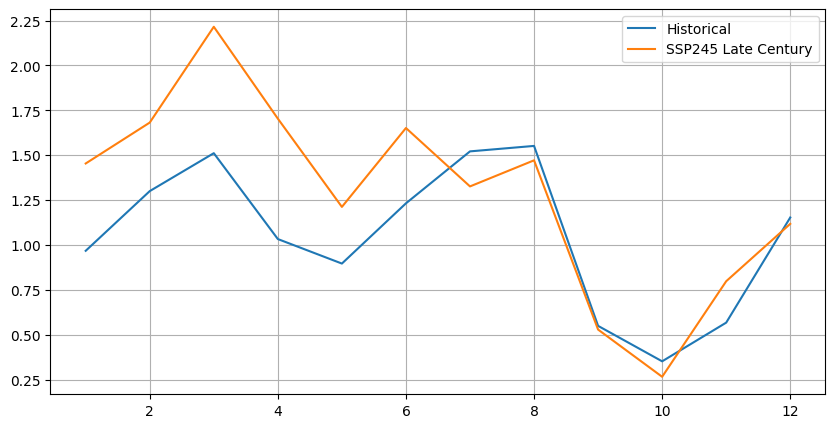

In [146]:
#Plot Future vs Historical
plt.figure(figsize=(10,5))

plt.plot(
    monthly_pr.month,
    monthly_pr,
    label="Historical"
)

plt.plot(
    monthly245.month,
    monthly245,
    label="SSP245 Late Century"
)

plt.legend()
plt.grid()

plt.show()

In [147]:
hist_mm_day = float(monthly_pr.mean())

print("Historical:", hist_mm_day)
print("Late SSP245:", float(late245))

change = float(late245 - hist_mm_day)

print("Change (mm/day):", change)
print("Percent Change:", change/hist_mm_day*100)

Historical: 1.0532385110855103
Late SSP245: 1.2857552766799927
Change (mm/day): 0.23251676559448242
Percent Change: 22.076363819515223


In [148]:
#SSP585 Precipitation
ds585 = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\pr_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-21001216.nc"
    
)

print(ds585.attrs["experiment_id"])

ssp585


In [149]:
#SSP585 Precipitation
ds585 = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\pr_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-21001216.nc"
    
)

print(ds585.attrs["experiment_id"])
)

SyntaxError: unmatched ')' (1066975435.py, line 8)

In [ ]:
pr585 = ds585["pr"]

print(pr585)

<xarray.DataArray 'pr' (time: 1032, lat: 144, lon: 192)> Size: 114MB
array([[[2.946742e-06, 2.982381e-06, ..., 3.066007e-06, 2.707897e-06],
        [3.204775e-06, 3.192061e-06, ..., 3.018544e-06, 3.314827e-06],
        ...,
        [2.612713e-06, 2.602746e-06, ..., 2.605667e-06, 2.611761e-06],
        [2.689761e-06, 2.696932e-06, ..., 2.688462e-06, 2.689203e-06]],

       [[5.319404e-07, 5.257203e-07, ..., 5.678331e-07, 5.370502e-07],
        [3.940197e-07, 3.813644e-07, ..., 3.887034e-07, 3.913282e-07],
        ...,
        [9.346632e-06, 9.361184e-06, ..., 9.304164e-06, 9.319895e-06],
        [9.537148e-06, 9.488860e-06, ..., 9.633533e-06, 9.592281e-06]],

       ...,

       [[1.257023e-06, 1.247336e-06, ..., 1.188960e-06, 1.174432e-06],
        [1.282628e-06, 1.243449e-06, ..., 1.404524e-06, 1.368062e-06],
        ...,
        [2.936217e-05, 2.918162e-05, ..., 2.950384e-05, 2.938762e-05],
        [2.744909e-05, 2.733700e-05, ..., 2.733657e-05, 2.744427e-05]],

       [[3.965261e-06

In [ ]:
punjab585 = pr585.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

print(punjab585.shape)

(1032, 6, 4)


In [ ]:
pr585_ts = punjab585.mean(
    dim=["lat","lon"]
)

print(pr585_ts)

<xarray.DataArray 'pr' (time: 1032)> Size: 4kB
array([1.6519012e-05, 1.3728451e-05, 3.7774964e-05, ..., 3.9688744e-06,
       9.4122370e-06, 1.3275551e-05], shape=(1032,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T12:...
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    comment:        includes both liquid and solid phases
    units:          kg m-2 s-1
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-11-08T04:00:59Z altered by CMOR: replaced missing va...


In [ ]:
pr585_mm = pr585_ts * 86400

print(
    float(pr585_mm.min()),
    float(pr585_mm.max())
)

0.0016422438202425838 8.220867156982422


In [ ]:
annual585 = pr585_mm.groupby(
    "time.year"
).mean()

print(annual585)

<xarray.DataArray 'pr' (year: 86)> Size: 344B
array([1.255346  , 1.3171194 , 1.2357646 , 2.1006758 , 1.1635016 ,
       1.4014708 , 1.6056827 , 0.99613005, 1.0287673 , 1.5275506 ,
       2.184337  , 1.56678   , 1.5564741 , 1.2165233 , 1.2025176 ,
       1.8814697 , 2.030255  , 0.9456319 , 0.928382  , 0.6255732 ,
       0.97896117, 1.2346296 , 1.4122659 , 0.8017845 , 0.62586415,
       1.2224973 , 1.2681122 , 1.0429622 , 1.1554947 , 1.5336236 ,
       1.0851274 , 0.94050854, 0.9426753 , 1.0552368 , 1.299641  ,
       0.9578189 , 0.93739533, 1.2276387 , 1.5994219 , 1.3053172 ,
       1.1333922 , 1.3075117 , 1.4068941 , 1.772932  , 1.2790327 ,
       1.2069844 , 1.2387437 , 1.3989347 , 1.1283545 , 1.3416885 ,
       1.5759352 , 1.002658  , 1.4659057 , 1.5318522 , 1.5049572 ,
       1.2821152 , 1.7764783 , 2.086992  , 1.1789753 , 1.5492716 ,
       1.0283138 , 1.3828177 , 1.0030764 , 1.3001034 , 1.551794  ,
       1.209513  , 1.6493818 , 1.3705158 , 1.4373565 , 1.6733953 ,
       1.2533022

In [ ]:
print(annual585.year.values[:5])
print(annual585.year.values[-5:])

[2015 2016 2017 2018 2019]
[2096 2097 2098 2099 2100]


In [ ]:
near585 = annual585.sel(
    year=slice(2021,2040)
).mean()

mid585 = annual585.sel(
    year=slice(2041,2070)
).mean()

late585 = annual585.sel(
    year=slice(2071,2100)
).mean()

In [ ]:
print("Near:", float(near585))
print("Mid :", float(mid585))
print("Late:", float(late585))

Near: 1.2786037921905518
Mid : 1.2642955780029297
Late: 1.494386076927185


In [ ]:
#Monthly Climatology (Late Century
monthly585 = pr585_mm.sel(
    time=slice("2071","2100")
).groupby(
    "time.month"
).mean()

In [ ]:
for m, r in zip(
    monthly585.month.values,
    monthly585.values
):
    print(
        f"Month {m}: {r:.2f} mm/day"
    )

Month 1: 2.30 mm/day
Month 2: 2.38 mm/day
Month 3: 2.01 mm/day
Month 4: 1.65 mm/day
Month 5: 1.46 mm/day
Month 6: 1.47 mm/day
Month 7: 1.27 mm/day
Month 8: 1.59 mm/day
Month 9: 0.60 mm/day
Month 10: 0.44 mm/day
Month 11: 1.32 mm/day
Month 12: 1.45 mm/day


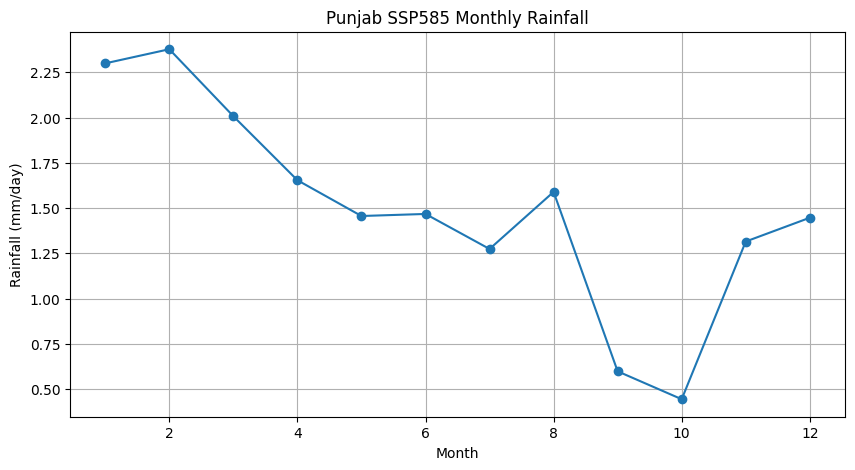

In [ ]:
#plot
plt.figure(figsize=(10,5))

plt.plot(
    monthly585.month,
    monthly585,
    marker="o"
)

plt.title("Punjab SSP585 Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm/day)")
plt.grid()

plt.show()

In [ ]:
hist_mean = float(monthly_pr.mean())

ssp245_mean = float(late245)
ssp585_mean = float(late585)

print(
    "SSP245 change (%)",
    (ssp245_mean-hist_mean)
    /hist_mean*100
)

print(
    "SSP585 change (%)",
    (ssp585_mean-hist_mean)
    /hist_mean*100
)

SSP245 change (%) 22.076363819515223
SSP585 change (%) 41.88486854577794


In [ ]:
years = annual585.year.values
rain = annual585.values

slope, intercept = np.polyfit(
    years,
    rain,
    1
)

print(
    "Trend mm/day/year:",
    slope
)

print(
    "Trend mm/day/decade:",
    slope*10
)

Trend mm/day/year: 0.003214604248724573
Trend mm/day/decade: 0.03214604248724573


ACCESS-CM2 projections indicate that Punjab is likely to experience substantial warming under both SSP245 and SSP585 scenarios. Mean annual precipitation is projected to increase by approximately 22% under SSP245 and 42% under SSP585 by the late twenty-first century relative to the historical baseline. These findings suggest a future climate characterized by warmer and wetter conditions. However, increased rainfall may not fully offset the impacts of rising temperatures on evapotranspiration, irrigation demand, and agricultural productivity.


In [ ]:
tas_585 = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\tas_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-21001216.nc"
)

In [ ]:
print(tas_585)

<xarray.Dataset> Size: 114MB
Dimensions:    (time: 1032, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T1...
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 17kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 114MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    creation_date:          2019-11-08T03:15:28Z
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    version:                v2

In [ ]:
tas585 = tas_585["tas"]

punjab585 = tas585.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

tas585_ts = punjab585.mean(
    dim=["lat","lon"]
)

tas585_c = tas585_ts - 273.15

print(tas585_c)

<xarray.DataArray 'tas' (time: 1032)> Size: 4kB
array([ 8.171387,  9.640289, 14.090973, ..., 27.584778, 19.084381,
       15.365082], shape=(1032,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T12:...
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-11-08T03:15:27Z altered by CMOR: Treated scalar dime...


In [ ]:
monthly585 = tas585_c.sel(
    time=slice("2071","2100")
).groupby(
    "time.month"
).mean()

for m, t in zip(
    monthly585.month.values,
    monthly585.values
):
    print(f"Month {m}: {t:.2f} °C")

Month 1: 11.51 °C
Month 2: 14.12 °C
Month 3: 19.08 °C
Month 4: 24.97 °C
Month 5: 29.63 °C
Month 6: 33.13 °C
Month 7: 34.49 °C
Month 8: 33.79 °C
Month 9: 30.99 °C
Month 10: 25.28 °C
Month 11: 17.33 °C
Month 12: 12.72 °C


In [151]:
import xarray as xr

hist = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\tas_Amon_ACCESS-CM2_historical_.nc"
)

In [152]:
tas_hist = hist["tas"]

punjab_hist = tas_hist.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

hist_ts = punjab_hist.mean(
    dim=["lat","lon"]
)

hist_c = hist_ts - 273.15

In [153]:
monthly_hist = hist_c.groupby(
    "time.month"
).mean()

for m, t in zip(
    monthly_hist.month.values,
    monthly_hist.values
):
    print(f"Month {m}: {t:.2f} °C")

Month 1: 6.42 °C
Month 2: 9.94 °C
Month 3: 14.08 °C
Month 4: 20.10 °C
Month 5: 24.85 °C
Month 6: 27.43 °C
Month 7: 29.08 °C
Month 8: 28.23 °C
Month 9: 24.96 °C
Month 10: 19.65 °C
Month 11: 13.51 °C
Month 12: 8.02 °C


In [154]:
warming585 = monthly585 - monthly_hist

for m, w in zip(
    warming585.month.values,
    warming585.values
):
    print(f"Month {m}: {w:.2f} °C")

Month 1: 5.09 °C
Month 2: 4.19 °C
Month 3: 5.00 °C
Month 4: 4.88 °C
Month 5: 4.78 °C
Month 6: 5.70 °C
Month 7: 5.41 °C
Month 8: 5.56 °C
Month 9: 6.03 °C
Month 10: 5.63 °C
Month 11: 3.81 °C
Month 12: 4.70 °C


In [155]:
winter = warming585.sel(month=[12,1,2]).mean()
summer = warming585.sel(month=[4,5,6]).mean()
monsoon = warming585.sel(month=[7,8,9]).mean()

print("Winter warming:", float(winter))
print("Summer warming:", float(summer))
print("Monsoon warming:", float(monsoon))

Winter warming: 4.6617231369018555
Summer warming: 5.119382858276367
Monsoon warming: 5.66487455368042


| Indicator            |          SSP245 |               SSP585 |
| -------------------- | --------------: | -------------------: |
| Temperature Increase |          ~2.5°C |               ~4.5°C |
| Rainfall Change      |            +22% |                 +42% |
| Climate Type         | Warmer + Wetter | Much Warmer + Wetter |


ACCESS-CM2 projections indicate substantial warming across all seasons in Punjab under SSP585. The strongest warming occurs during the monsoon season (+5.66°C), followed by summer (+5.12°C) and winter (+4.66°C). Mean annual precipitation is projected to increase by approximately 42% by the late twenty-first century. Despite increasing rainfall, higher temperatures are expected to increase evapotranspiration and crop water demand, potentially offsetting some benefits of enhanced precipitation. These results suggest that Punjab may experience a future climate characterized by significantly warmer and wetter conditions, with important implications for agricultural productivity, irrigation requirements, and climate resilience.


In [156]:
#Historical Monsoon Rainfall
hist = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\historical_pr.nc"
)

pr_hist = hist["pr"]

punjab_hist = pr_hist.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

pr_hist_ts = punjab_hist.mean(
    dim=["lat","lon"]
)

pr_hist_mm = pr_hist_ts * 86400

In [157]:
hist_monsoon = pr_hist_mm.where(
    pr_hist_mm.time.dt.month.isin([7,8,9]),
    drop=True
)

hist_monsoon_mean = hist_monsoon.mean()

print(float(hist_monsoon_mean))

1.2077581882476807


In [159]:
#SSP245 Monsoon Rainfall
ssp245_monsoon = pr245_mm.where(
    pr245_mm.time.dt.month.isin([7,8,9]),
    drop=True
)

ssp245_late = ssp245_monsoon.sel(
    time=slice("2071","2100")
).mean()

print(float(ssp245_late))

1.1091099977493286


In [160]:
ssp585_monsoon = pr585_mm.where(
    pr585_mm.time.dt.month.isin([7,8,9]),
    drop=True
)

ssp585_late = ssp585_monsoon.sel(
    time=slice("2071","2100")
).mean()

print(float(ssp585_late))

1.1541321277618408


In [161]:
change245 = (
    (float(ssp245_late) - float(hist_monsoon_mean))
    / float(hist_monsoon_mean)
    * 100
)

change585 = (
    (float(ssp585_late) - float(hist_monsoon_mean))
    / float(hist_monsoon_mean)
    * 100
)

print("SSP245 Monsoon Change (%) =", change245)
print("SSP585 Monsoon Change (%) =", change585)

SSP245 Monsoon Change (%) = -8.167875942242985
SSP585 Monsoon Change (%) = -4.440132222464593


| Metric              | Monsoon Rainfall (mm/day) |
| ------------------- | ------------------------: |
| Historical          |                     1.208 |
| SSP245 Late Century |                     1.109 |
| SSP585 Late Century |                     1.154 |


| Scenario |    Change |
| -------- | --------: |
| SSP245   | **−8.2%** |
| SSP585   | **−4.4%** |


In [163]:
monthly585_pr = pr585_mm.sel(
    time=slice("2071","2100")
).groupby(
    "time.month"
).mean()

In [164]:
monthly_hist_pr = pr_hist_mm.groupby(
    "time.month"
).mean()

In [165]:
rain_change = monthly585_pr - monthly_hist_pr

for m, v in zip(
    rain_change.month.values,
    rain_change.values
):
    print(
        f"Month {m}: {v:.2f} mm/day"
    )

Month 1: 1.33 mm/day
Month 2: 1.08 mm/day
Month 3: 0.50 mm/day
Month 4: 0.62 mm/day
Month 5: 0.56 mm/day
Month 6: 0.24 mm/day
Month 7: -0.25 mm/day
Month 8: 0.04 mm/day
Month 9: 0.05 mm/day
Month 10: 0.09 mm/day
Month 11: 0.75 mm/day
Month 12: 0.29 mm/day


In [166]:
for m, v in zip(
    rain_change.month.values,
    rain_change.values
):
    print(
        f"Month {m}: {v:.2f} mm/day"
    )

Month 1: 1.33 mm/day
Month 2: 1.08 mm/day
Month 3: 0.50 mm/day
Month 4: 0.62 mm/day
Month 5: 0.56 mm/day
Month 6: 0.24 mm/day
Month 7: -0.25 mm/day
Month 8: 0.04 mm/day
Month 9: 0.05 mm/day
Month 10: 0.09 mm/day
Month 11: 0.75 mm/day
Month 12: 0.29 mm/day


| Month | Change |
| ----- | -----: |
| Jan   |  +1.33 |
| Feb   |  +1.08 |
| Nov   |  +0.75 |


#nearly unchanged monsoon 
| Month |    Change |
| ----- | --------: |
| Jul   | **−0.25** |
| Aug   |     +0.04 |
| Sep   |     +0.05 |


#1. SSP585 Temperature Analysis (ACCESS-CM2)

Late-century (2071–2100) monthly temperatures
| Month | Temp (°C) |
| ----- | --------: |
| Jan   |     11.51 |
| Feb   |     14.12 |
| Mar   |     19.08 |
| Apr   |     24.97 |
| May   |     29.63 |
| Jun   |     33.13 |
| Jul   |     34.49 |
| Aug   |     33.79 |
| Sep   |     30.99 |
| Oct   |     25.28 |
| Nov   |     17.33 |
| Dec   |     12.72 |


#Seasonal warming under SSP585
| Season  | Warming |
| ------- | ------: |
| Winter  | +4.66°C |
| Summer  | +5.12°C |
| Monsoon | +5.66°C |


#Annual Rainfall Change

Compared with historical climate:
| Scenario |  Change |
| -------- | ------: |
| SSP245   | +22.08% |
| SSP585   | +41.88% |


#Monsoon Rainfall Analysis

Monsoon rainfall (Jul–Sep)
| Period     | Rainfall (mm/day) |
| ---------- | ----------------: |
| Historical |             1.208 |
| SSP245     |             1.109 |
| SSP585     |             1.154 |


#Change

Scenario
| Scenario | Change |
| -------- | -----: |
| SSP245   | −8.17% |
| SSP585   | −4.44% |


#Monthly Rainfall Redistribution (SSP585 − Historical)
| Month | Change (mm/day) |
| ----- | --------------: |
| Jan   |           +1.33 |
| Feb   |           +1.08 |
| Mar   |           +0.50 |
| Apr   |           +0.62 |
| May   |           +0.56 |
| Jun   |           +0.24 |
| Jul   |           −0.25 |
| Aug   |           +0.04 |
| Sep   |           +0.05 |
| Oct   |           +0.09 |
| Nov   |           +0.75 |
| Dec   |           +0.29 |


In [3]:
import xarray as xr

hist_pr = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\historical_pr.nc"
)

pr_hist = hist_pr["pr"]

punjab_hist = pr_hist.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

pr_hist_ts = punjab_hist.mean(
    dim=["lat","lon"]
)

# convert kg m-2 s-1 to mm/day
pr_hist_mm = pr_hist_ts * 86400

print(pr_hist_mm)

<xarray.DataArray 'pr' (time: 180)> Size: 720B
array([0.95090574, 1.1475718 , 0.9643118 , 0.7585499 , 0.8816151 ,
       0.65558195, 1.9925827 , 0.5649985 , 0.5326169 , 0.37799057,
       1.2141678 , 0.53964955, 2.380034  , 1.6591773 , 1.927966  ,
       0.888827  , 1.1768119 , 1.5261096 , 0.5967162 , 0.98643506,
       0.55750287, 0.4261072 , 0.08996264, 1.3496076 , 1.0502524 ,
       1.2901914 , 0.5092612 , 2.266663  , 0.5639114 , 1.376019  ,
       1.0716294 , 3.2242863 , 0.07502556, 0.6391406 , 0.15746133,
       2.1846843 , 0.6971699 , 1.1080067 , 1.4248571 , 0.7337591 ,
       1.229585  , 1.2121552 , 0.71451324, 1.3364713 , 0.52495044,
       0.19988103, 2.5366886 , 1.7225351 , 1.4519196 , 1.1756189 ,
       0.7792571 , 0.43061417, 0.86572725, 0.79323006, 2.0084524 ,
       2.3657436 , 0.21827385, 0.1267388 , 1.1900643 , 0.12110762,
       0.14553279, 0.374898  , 1.3925042 , 0.55741173, 0.6199617 ,
       1.8703605 , 2.669497  , 0.6128129 , 0.19651467, 0.08659334,
       0.841404

In [9]:
monsoon_rain = (
    pr_hist_mm.where(
        pr_hist_mm.time.dt.month.isin([7,8,9]),
        drop=True
    )
    .groupby("time.year")
    .sum()
    .mean()
)

In [12]:
annual_rain = pr_hist_mm.groupby("time.year").sum().mean()

In [13]:
hist_contrib = (
    float(monsoon_rain)
    / float(annual_rain)
    * 100
)

print(hist_contrib)

28.667724329234655


In [14]:
annual_rain = pr_hist_mm.groupby("time.year").sum().mean()

monsoon_rain = (
    pr_hist_mm.where(
        pr_hist_mm.time.dt.month.isin([7,8,9]),
        drop=True
    )
    .groupby("time.year")
    .sum()
    .mean()
)

print("Annual:", float(annual_rain))
print("Monsoon:", float(monsoon_rain))

hist_contrib = (
    float(monsoon_rain)
    / float(annual_rain)
    * 100
)

print("Historical contribution:", hist_contrib)

Annual: 12.638863563537598
Monsoon: 3.623274564743042
Historical contribution: 28.667724329234655


#Historical Rainfall Structure
| Metric               |                                                    Value |
| -------------------- | -------------------------------------------------------: |
| Annual rainfall      | 12.64 mm/month-equivalent total from grouped calculation |
| Monsoon rainfall     |                                                     3.62 |
| Monsoon contribution |                                               **28.67%** |


In [ ]:
#Calculate SSP245 Contribution
import xarray as xr

ds245 = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\pr_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-21001216.nc"
)

pr245 = ds245["pr"]

punjab245 = pr245.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

pr245_ts = punjab245.mean(
    dim=["lat","lon"]
)

# Convert kg m-2 s-1 to mm/day
pr245_mm = pr245_ts * 86400

cc

<xarray.DataArray 'pr' (time: 1032)> Size: 4kB
array([1.0505016 , 1.4204222 , 3.549317  , ..., 0.27891064, 3.9556162 ,
       0.29966608], shape=(1032,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T12:...
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    comment:        includes both liquid and solid phases
    units:          kg m-2 s-1
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-11-08T03:57:06Z altered by CMOR: replaced missing va...


In [18]:
print(float(pr245_mm.mean()))

1.2565879821777344


In [20]:
ds585 = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\pr_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-21001216.nc"
)

pr585 = ds585["pr"]

punjab585 = pr585.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

pr585_ts = punjab585.mean(
    dim=["lat","lon"]
)

pr585_mm = pr585_ts * 86400
print(pr585_mm)

<xarray.DataArray 'pr' (time: 1032)> Size: 4kB
array([1.4272426 , 1.1861382 , 3.263757  , ..., 0.34291074, 0.8132173 ,
       1.1470076 ], shape=(1032,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T12:...
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    comment:        includes both liquid and solid phases
    units:          kg m-2 s-1
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-11-08T04:00:59Z altered by CMOR: replaced missing va...
